# Protein Prediction Model

## Setup

### Imports

In [3]:
import tensorflow as tf
import yggdrasil_decision_forests as ydf
import keras # Must be imported, otherwise tf breaks the IDE
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import pandas as pd
import datetime as dt
import csv

print(tf.__version__)

2.15.0


### Data Aquisition

Data needs to be imported from its raw .xls format then processed into separate dataframes for each protein's items.

In [4]:
data_dir = pathlib.Path.cwd() / "data"
xls_files = list(data_dir.glob("*.xls"))
print(f"Found {len(xls_files)} .xls files in the data directory.")

multipliers_dir = pathlib.Path.cwd() / "multipliers"
multiplier_files = list(multipliers_dir.glob("*.csv"))
print(f"Found {len(multiplier_files)} .csv files in the multipliers directory.")

Found 36 .xls files in the data directory.
Found 4 .csv files in the multipliers directory.


### Data Formatting

Data needs to be cleaned from report generator formatting and split into usable dataframes.

In [5]:
time_dict : dict[dt.time, int] = {}  # Initialize an empty dictionary to store the mapping of time intervals to integers
# Create a mapping of dt.time objects starting at 10:30 AM and ending at 10:00 PM in 15 minute intervals to integers starting at 0 and ending at 47 (32 intervals in total)
current_time = dt.time(hour=10, minute=30)  # Start time at 10:30 AM
current_time = dt.datetime.combine(dt.date.today(), current_time)  # Combine the current time with today's date to create a datetime object for easier manipulation
while current_time < dt.datetime.combine(dt.date.today(), dt.time(hour=22, minute=0)):  # End time at 10:00 PM
    time_dict[current_time.time()] = len(time_dict)  # Map the current time to the next integer in the sequence
    current_time += dt.timedelta(minutes=15)  # Increment the current time by 15 minutes

In [6]:
multiplier_dict : dict[str, int] = {}  # Initialize an empty dictionary to store the mapping of item names to their respective multipliers
# Read the multipliers from the CSV files and populate the multiplier_dict
for file in multiplier_files:
    with open(file, mode='r') as csvfile:
        reader = csv.reader(csvfile)
        for row in reader:
            # Skip the first row if it contains headers (assuming the first row contains headers if it has non-numeric values in the second column)
            if reader.line_num == 1 and (len(row) < 2 or not row[1].strip().isdigit()):
                continue
            if len(row) >= 2:  # Ensure that the row has at least two columns (item name and multiplier)
                item_name = row[0].strip()  # Get the item name and remove any leading/trailing whitespace
                try:
                    multiplier = int(row[1].strip())  # Get the multiplier and convert it to an integer
                    multiplier_dict[item_name] = multiplier  # Add the item name and multiplier to the dictionary
                except ValueError:
                    print(f"Warning: Could not convert multiplier '{row[1]}' for item '{item_name}' to an integer. Skipping this entry.")

In [7]:
def convert_to_24h(time_str: str) -> dt.datetime:
    '''
    Convert a time string in the format "HH:MM AM/PM - HH:MM AM/PM" 
    to a datetime.time object in 24-hour format.

    Args:
        time_str (str): The time string to convert.

    Returns:
        dt.time: The start time in 24-hour format.
    '''
    time_components = time_str.split()  # Split the time string into components by whitespace
    start_time = time_components[0]     # The first component is the start time (e.g., "10:00")
    am_pm = time_components[3]          # The fourth component is the AM/PM indicator for the end time (e.g., "AM" or "PM")
    hours, minutes = map(int, start_time.split(':'))    # Split the start time into hours and minutes and convert to integers
    if am_pm == 'PM' and hours != 12:       # If the time is in PM and not 12 PM, add 12 to convert to 24-hour format
        hours += 12
    elif am_pm == 'AM' and hours == 12:     # If the time is 12 AM, set hours to 0 to convert to 24-hour format
        hours = 0
    return dt.datetime.combine(dt.date.today(), dt.time(hour=hours, minute=minutes))  # Return the start time as a datetime.time object in 24-hour format

In [8]:
def df_cleaner(df: pd.DataFrame, protein: str) -> pd.DataFrame:
    '''
    Clean the input DataFrame by converting time intervals to 24-hour format and mapping them to integers.

    Args:
        df (pd.DataFrame): The raw input DataFrame directly read from the Excel file.
        protein (str): The name of the protein for which to create a dataframe.

    Returns:
        pd.DataFrame: The cleaned and collapsed DataFrame with a new 'Time Interval Int' column.
    '''


    # Clean the raw dataframe and encode metadata.
    df = df.iloc[6:, :]         # Drop the first 6 rows which contain metadata and are not part of the actual data
    df = df.drop(df.columns[1], axis=1) # Drop the second column containing only the word "Time"
    df = df[df.iloc[:, 0] != "Sales Mix Time Interval Report"]  # Drop rows where the first column contains "Sales Mix Time Interval Report"
    df = df[df.iloc[:, 0] != "Store: Indian Trail FSU, 02965"]  # Drop rows where the first column contains "Store: Indian Trail FSU, 02965"
    df = df[df.iloc[:, 2] != "Totals:"] # Drop rows where the fourth column contains "Totals:"
    df = df.dropna(axis=1, how='all')   # Drop columns where all values are NaN (holdovers from PDF formatting)
    df.rename(columns={df.columns[0]: 'Item', df.columns[1]: 'Time Interval', df.columns[2]: 'Monday',
                    df.columns[3]: 'Tuesday', df.columns[4]: 'Wednesday', df.columns[5]: 'Thursday',
                    df.columns[6]: 'Friday', df.columns[7]: 'Saturday'}, inplace=True)
    for col in df.columns[2:]:    # 2:-1 to skip the 'Item', 'Time Interval', and 'Start Time' columns, which are not sales data columns
        df[col] = pd.to_numeric(df[col], errors='coerce')   # Convert the sales data columns to numeric, coercing errors to NaN
    df = df.dropna(how='all')   # Drop rows where all values are NaN
    df.reset_index(drop=True, inplace=True) # Reset the index of the dataframe after dropping rows


    # Map time intervals to integers and drop rows not containing item names or time intervals.
    df['Time Interval'] = df.iloc[:, 1].map(lambda x: convert_to_24h(x) if pd.notnull(x) else np.nan)
    df['Time Interval'] = df['Time Interval'].map(lambda x: time_dict.get(x.time(), np.nan) if pd.notnull(x) else np.nan)
    df = df[df['Time Interval'].notnull() | df['Item'].notnull()]  # Drop rows where the 'Time Interval' column has null values after mapping
    df.reset_index(drop=True, inplace=True) # Reset the index of the dataframe after dropping rows


    # Create a dictionary of DataFrames for each item, split by item name.
    df_dict : dict[str, pd.DataFrame] = {}  # Initialize an empty dictionary to store the dataframes for each item
    for item in df['Item'].unique():        # Only create dataframes for unique, non-null item names in the 'Item' column
        if pd.notnull(item):
            df_dict[item] = df[df['Item'] == item].copy()
    name_idx_start = 0
    name_idx_end = 0
    for index, row in df.iterrows():        # Grab each section of the dataframe corresponding to each item and store it in the dictionary with the item name as the key
        if pd.notnull(row['Item']):
            if name_idx_end != 0:           # First iteration guard
                df_dict[str(df.iloc[name_idx_start, 0])] = df.iloc[name_idx_start + 1:name_idx_end, :].copy()
                df_dict[str(df.iloc[name_idx_start, 0])].Name = str(df.iloc[name_idx_start, 0])  # Store the item name in the dataframe metadata for later use
            name_idx_start = name_idx_end       # Move the start index to the current end index for the next item section
            name_idx_end = name_idx_start + 1   # Move the end index to the next row to start looking for the next item name
        else:                               # If the current row does not contain an item name, move the end index down to continue looking for the next item name
            name_idx_end += 1
            continue

    # Process the last item after the loop finishes
    if name_idx_end != 0:  # Only process if at least one item was found
        df_dict[str(df.iloc[name_idx_start, 0])] = df.iloc[name_idx_start + 1:name_idx_end, :].copy()

    # Final cleaning pass for timeframe sorting and uniform intervals.
    for key in df_dict.keys():  # Adjust each dataframe to keep only the relevant data.
        df_dict[key].drop(df_dict[key].columns[0], axis=1, inplace=True)    # Item name and days of the week are stored in dataframe metadata, so drop the first two rows which contain this information
        df_dict[key]['Time Interval'] = df_dict[key]['Time Interval'].astype(int)  # Cast the time interval column to integers
        df_dict[key].reset_index(drop=True, inplace=True)                   # Reset the index of the dataframe after dropping rows and columns

    for key in df_dict.keys():
    # Ensure that all mapped time intervals are present in the dataframe, and if not, add rows with NaN values for the sales data columns for those time intervals
        for time_interval in time_dict.values():
            if time_interval not in df_dict[key]['Time Interval'].values:
                new_row = {'Time Interval': time_interval}
                df_dict[key] = pd.concat([df_dict[key], pd.DataFrame([new_row])], ignore_index=True)  # Add the new row to the dataframe

    # Check for uniform time intervals and force typings to int.
    for key in df_dict.keys():  # Final check to ensure that all dataframes have the same time intervals and are sorted by time interval
        assert set(df_dict[key]['Time Interval'].values) == set(time_dict.values()), f"Dataframe for item '{key}' is missing some time intervals."
        df_dict[key].sort_values(by='Time Interval', inplace=True)
        for col in df_dict[key].columns[1:]:    # 1: to skip the 'Time Interval' column, which is not sales data
            df_dict[key][col] = pd.to_numeric(df_dict[key][col], errors='coerce').fillna(0).astype(int)   # Ensure that all sales data columns are numeric, coercing errors to NaN
        df_dict[key].reset_index(drop=True, inplace=True)
                        
    # Apply multipliers
    for key in df_dict.keys():
        if key not in multiplier_dict:
            multiplier_dict[key] = 1  # If the item does not have a specified multiplier, default to 1 (no change)
        df_dict[key].iloc[:, 1:] *= multiplier_dict.get(key, 1)  # Apply the multiplier for each item, defaulting to 1 if not found

    # Collapse all DataFrames into a single DataFrame by summing the sales data across all items for each time interval.
    summed_df = pd.DataFrame()  # Initialize an empty dataframe to store the summed sales data for each time interval across all items
    for key in df_dict.keys():
        if summed_df.empty:  # If the summed_df is empty, initialize it with the first dataframe
            summed_df = df_dict[key].copy()
            summed_df.iloc[:, 1:] = 0  # Set all sales data columns to 0 to prepare for summation
        summed_df.iloc[:, 1:] += df_dict[key].iloc[:, 1:]  # Sum the sales data columns across all items for each time interval

    return summed_df

### Data Visualization

Render a 3D plot of summed sales for all items across each time interval and day of the week.

WARNING *** file size (113901) not 512 + multiple of sector size (512)
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** file size (120995) not 512 + multiple of sector size (512)
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** file size (115110) not 512 + multiple of sector size (512)
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** file size (90403) not 512 + multiple of sector size (512)
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** file size (115014) not 512 + multiple of sector size (512)
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** file size (136217) not 512 + multiple of sector size (512)
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** file size (102338) not 512 + multiple of sector size (512)
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is no

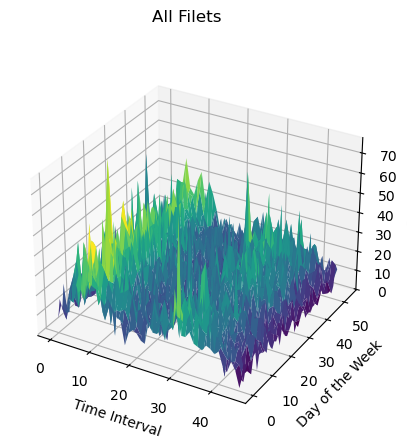

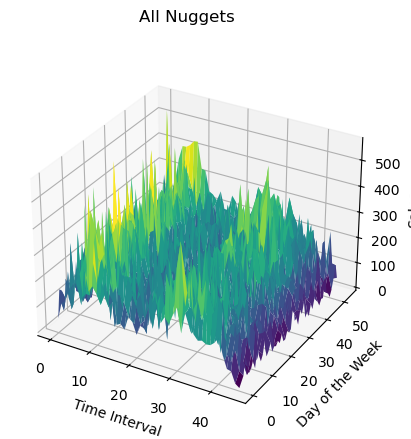

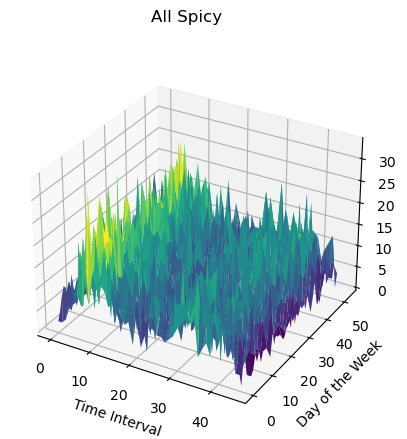

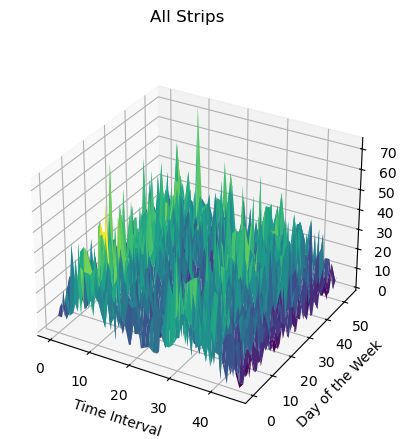

In [9]:
# Show a 3D plot of the summed sales data across all items for each time interval to visualize overall sales trends throughout the day
df_list : list[tuple[pd.DataFrame, str, dt.date]] = []

for file in xls_files:
    df = pd.read_excel(file)  # Read each Excel file into a DataFrame
    df_list.append((df, file.stem, dt.date.today()))  # Append the raw DataFrame to the list for potential future use

cleaned_df_list : list[tuple[pd.DataFrame, str, dt.date]]= []
for df in df_list:
    cleaned_df = df_cleaner(df[0], df[1])  # Clean each raw dataframe and get the summed sales data for all items
    cleaned_df_list.append((cleaned_df, df[1], df[2]))  # Append the cleaned DataFrame to the list
    

filets_list : list[tuple[pd.DataFrame, str, dt.date]] = []
nuggets_list : list[tuple[pd.DataFrame, str, dt.date]] = []
spicy_list : list[tuple[pd.DataFrame, str, dt.date]] = []
strips_list : list[tuple[pd.DataFrame, str, dt.date]] = []

for df in cleaned_df_list:
    if "filets" in df[1].lower():
        filets_list.append(df)
    elif "nuggets" in df[1].lower():
        nuggets_list.append(df)
    elif "spicy" in df[1].lower():
        spicy_list.append(df)
    elif "strips" in df[1].lower():
        strips_list.append(df)

print(f"Found {len(filets_list)} filets dataframes, {len(nuggets_list)} nuggets dataframes, {len(spicy_list)} spicy dataframes, and {len(strips_list)} strips dataframes.")

all_proteins : list[list[tuple[pd.DataFrame, str, dt.date]]] = [filets_list, nuggets_list, spicy_list, strips_list]  # Create a list of tuples containing the dataframes for each protein category]
stitched_protein : list[pd.DataFrame] = []  # Initialize an empty list to store the stitched dataframes for each protein category
# Stitch together df end to end
for protein in all_proteins:
    for i in range(len(protein)):
        if i != 0:
            protein[i][0].rename(columns={protein[i][0].columns[1]: 'Monday'+str(i), protein[i][0].columns[2]: 'Tuesday'+str(i), protein[i][0].columns[3]: 'Wednesday'+str(i),
                                protein[i][0].columns[4]: 'Thursday'+str(i), protein[i][0].columns[5]: 'Friday'+str(i), protein[i][0].columns[6]: 'Saturday'+str(i)}, 
                                inplace=True)

    for i in range(len(protein)):
        if i == 0:
            stitched_protein.append(protein[i][0].copy())
        else:
            stitched_protein[-1] = pd.concat([stitched_protein[-1], protein[i][0].iloc[:, 1:]], axis=1)


protein_labels = ['Filets', 'Nuggets', 'Spicy', 'Strips']

for i, protein in enumerate(stitched_protein):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    x = protein['Time Interval'].to_numpy().clip(0, 46) 
    y = np.arange(protein.shape[1] - 1)
    X, Y = np.meshgrid(x, y)
    Z = protein.iloc[:, 1:].values.T
    ax.plot_surface(X, Y, Z, cmap='viridis')
    ax.set_xlabel('Time Interval')
    ax.set_ylabel('Day of the Week')
    ax.set_zlabel('Sales')
    fig.suptitle(f'All {protein_labels[i]}')
    plt.show()

## Tensor Preparation

Each data point is given higher dimensionality to accomodate further attributes.

In [13]:
def tensor_constructor(tensor_df_list: list[tuple[pd.DataFrame, str, dt.date]]) -> pd.DataFrame:    
    # Time interval, day of the week (0-5), sales, day of month (1-31), day of year (1-366), week of year (1-52), month of year (1-12), year
    tensor_tuples : list[tuple[np.uint16, np.uint16, np.uint16, np.uint16, np.uint16, np.uint16, np.uint16, np.uint16]] = []
    for i, df in enumerate(tensor_df_list):
        date_str = df[1].split('_') 
        month = int(date_str[0])
        day = int(date_str[1])
        new_date = dt.date(year=2026, month=month, day=day)
        tensor_df_list[i] = (df[0], df[1], new_date)

    for df in tensor_df_list:
        for index, row in df[0].iterrows():
            time_interval = np.uint16(row['Time Interval'])
            for i, col in enumerate(df[0].columns[1:]):  # 1: to skip the 'Time Interval' column
                day_of_week = np.uint16(df[2].weekday() + i)  # Get the day of the week from the date in the dataframe metadata (0=Monday, 6=Sunday)
                sales = np.uint16(row[col])
                day_of_month = np.uint16(df[2].day + i)
                day_of_year = np.uint16(df[2].timetuple().tm_yday + i)
                week_of_year = np.uint16(df[2].isocalendar()[1])
                month_of_year = np.uint16(df[2].month)
                year = np.uint16(df[2].year)
                tensor_tuples.append((time_interval, day_of_week, sales, day_of_month, day_of_year, week_of_year, month_of_year, year))

    tensor_df = pd.DataFrame(tensor_tuples, columns=['Time Interval', 'Day of Week', 'Sales', 'Day of Month', 'Day of Year', 'Week of Year', 'Month of Year', 'Year'])
    return tensor_df

### TensorFlow Tensor Formatting
DataFrames are formatted and converted into tf Tensor objects for DNN application.

In [16]:
all_protein_formatted_df : list[pd.DataFrame] = []
all_protein_tensors : list[list[tf.Tensor]] = [[],[],[],[]]

for protein in all_proteins:
    all_protein_formatted_df.append(tensor_constructor(protein)) # As per all_proteins, order is filets, nuggets, spicy, strips

for i, protein in enumerate(all_protein_formatted_df):
    tensor_list : list[tf.Tensor] = []
    for row in protein.values:
        tensor_list.append(tf.convert_to_tensor(row))
    all_protein_tensors[i] = tensor_list

filet_tensors : list[tf.Tensor] = all_protein_tensors[0]
nugget_tensors : list[tf.Tensor] = all_protein_tensors[1]
spicy_tensors : list[tf.Tensor] = all_protein_tensors[2]
strip_tensors : list[tf.Tensor] = all_protein_tensors[3]

### Yggdrasil Decision Forests Formatting
DataFrames are formatted and separated for YDF application.

In [17]:
filet_formatted_df = all_protein_formatted_df[0]
nugget_formatted_df = all_protein_formatted_df[1]
spicy_formatted_df = all_protein_formatted_df[2]
strip_formatted_df = all_protein_formatted_df[3]

## Model

Two model types are used for the purpose of comparison: Deep Neural Network (TensorFlow) and Gradient Boosted Decision Tree (Yggdrasil Decision Forests).

### Deep Neural Network

#### Architecture

### Gradient Boosted Decision Tree